<a href="https://colab.research.google.com/github/AnikKushwaha/AnikKushwaha/blob/master/Jobwork3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install deepface opencv-python matplotlib seaborn scikit-learn


In [3]:

import os as sys_ops
import numpy as np_utils
from deepface import DeepFace as FaceEmbedder

from sklearn.datasets import fetch_lfw_people as load_lfw
import cv2 as vision
import matplotlib.pyplot as plotter
import seaborn as heatmap_tool
from sklearn.model_selection import train_test_split as data_split
from sklearn.svm import SVC as SupportVectorClassifier
from sklearn.metrics import accuracy_score as acc_score, classification_report as cls_report, confusion_matrix as conf_mat

from joblib import dump as save_model, load as load_model


In [4]:

face_data = load_lfw(min_faces_per_person=50, resize=0.5)

face_images = face_data.images
person_ids = face_data.target
person_names = face_data.target_names
print(" Face dataset successfully imported!")
print(" Total image samples:", len(face_images))
print(" Unique individuals:", len(person_names))


 Face dataset successfully imported!
 Total image samples: 1560
 Unique individuals: 12


In [6]:
face_signatures = []
class_targets = []

for index, single_img in enumerate(face_images):

    converted_img = vision.cvtColor(single_img, vision.COLOR_GRAY2RGB)

    try:
        encoded_face = FaceEmbedder.represent(
            converted_img,
            model_name="Facenet512",
            enforce_detection=False
        )

        face_signatures.append(encoded_face[0]["embedding"])
        class_targets.append(person_ids[index])

    except Exception:
        pass

face_signatures = np_utils.asarray(face_signatures)
class_targets = np_utils.asarray(class_targets)

print(f" Feature vectors generated successfully! Total: {len(face_signatures)}")


 Feature vectors generated successfully! Total: 1560


In [7]:
train_data, test_data, train_labels, test_labels = data_split(
    face_signatures,
    class_targets,
    test_size=0.20,
    random_state=101
)

In [8]:
svm_classifier = SupportVectorClassifier(kernel='linear', probability=True)

svm_classifier.fit(train_data, train_labels)

save_model(svm_classifier, "svm_face_recognizer.joblib")
save_model(person_names, "identity_mapping.joblib")

print("Model training finished successfully!")

Model training finished successfully!



 Model Accuracy: 36.54%

 Performance Summary:
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        15
     Colin Powell       0.00      0.00      0.00        41
  Donald Rumsfeld       0.00      0.00      0.00        26
    George W Bush       0.37      1.00      0.54       114
Gerhard Schroeder       0.00      0.00      0.00        22
      Hugo Chavez       0.00      0.00      0.00        13
   Jacques Chirac       0.00      0.00      0.00        13
    Jean Chretien       0.00      0.00      0.00         6
    John Ashcroft       0.00      0.00      0.00         8
Junichiro Koizumi       0.00      0.00      0.00         9
  Serena Williams       0.00      0.00      0.00         9
       Tony Blair       0.00      0.00      0.00        36

         accuracy                           0.37       312
        macro avg       0.03      0.08      0.04       312
     weighted avg       0.13      0.37      0.20       312



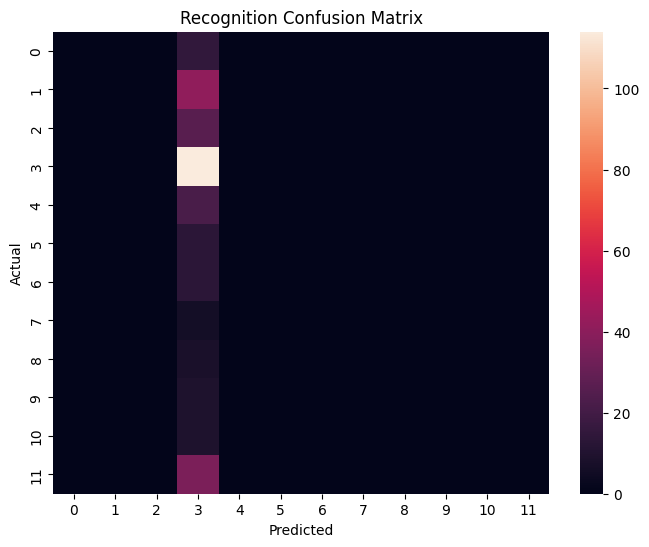

In [9]:
predicted_labels = svm_classifier.predict(test_data)

test_accuracy = acc_score(test_labels, predicted_labels)
print(f"\n Model Accuracy: {round(test_accuracy * 100, 2)}%")

print("\n Performance Summary:")
print(cls_report(test_labels, predicted_labels, target_names=person_names))

matrix = conf_mat(test_labels, predicted_labels)

plotter.figure(figsize=(8, 6))
heatmap_tool.heatmap(matrix, annot=False, fmt='g')
plotter.title("Recognition Confusion Matrix")
plotter.xlabel("Predicted")
plotter.ylabel("Actual")
plotter.show()

In [10]:
random_idx = np_utils.random.randint(len(test_data))

actual_identity = person_names[test_labels[random_idx]]
predicted_identity = person_names[predicted_labels[random_idx]]

print("Actual Person   :", actual_identity)
print("Predicted Person:", predicted_identity)

Actual Person   : George W Bush
Predicted Person: George W Bush
